# Engenharia de Atributos: Análise RFM

Neste notebook, consolidamos os dados transacionais para criar o perfil de **Recência, Frequência e Valor Monetário (RFM)** de cada cliente.

### O que é RFM?
- **Recência (R)**: Dias desde a última compra do cliente.
- **Frequência (F)**: Quantidade total de compras realizadas.
- **Valor Monetário (M)**: Valor total gasto pelo cliente.

In [37]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando os dados pré-processados
df = pd.read_csv('../data/df_clientes_header.csv')


### 1. Cálculo do RFM por Cliente

In [38]:
df_rfm = df.rename(columns={
    'valor_total': 'Monetario',
    'qtde_compras': 'Frequencia'
})

data_hoje = pd.to_datetime('2026-06-01')

df_rfm['Recencia'] = (data_hoje - pd.to_datetime(df_rfm['data_da_ultima_compra'])).dt.days

print("Base carregada para análise RFM.")

Base carregada para análise RFM.


In [39]:
df_rfm = df_rfm[['cliente_id','Recencia', 'Frequencia', 'Monetario']]
df_rfm['cliente_id'] = df_rfm['cliente_id'].replace('CUST-', '', regex=True).astype({'cliente_id': int})
df_rfm = df_rfm.set_index('cliente_id')   


In [40]:
df_rfm.head()

,Recencia,Frequencia,Monetario
cliente_id,,,
1000,11.0,7,500.67
1001,13.0,8,700.57
1002,18.0,6,246.12
1003,14.0,3,619.02
1004,16.0,6,454.61


### Tratamento de Outliers

Tratamento de Outliers: Antes de classificar, verifique se existem clientes com valores monetários ou frequências "astronômicas" que podem distorcer os grupos.

Método do Intervalo Interquartil (IQR)É o método mais robusto e amplamente utilizado em Ciência de Dados. Ele baseia-se na dispersão estatística dos dados.Como funciona:
 - Q1 (25º percentil): O valor abaixo do qual estão 25% dos dados.
 - Q3 (75º percentil): O valor abaixo do qual estão 75% dos dados.
 - IQR: A diferença entre Q3 e Q1 ($IQR = Q3 - Q1$).
 - Limites: Qualquer valor fora do intervalo $[Q1 - 1.5 \times IQR, Q3 + 1.5 \times IQR]$ é considerado um outlier.
 
Implementação Sugerida para o seu df_rfm:


In [41]:
def remover_outliers_iqr(df, colunas):
    df_clean = df.copy()
    for col in colunas:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        
        # Filtrando os dados
        df_clean = df_clean[(df_clean[col] >= limite_inferior) & (df_clean[col] <= limite_superior)]
    return df_clean

In [42]:
# Aplicando nas colunas de RFM
colunas_rfm = ['Recencia', 'Frequencia', 'Monetario']
df_rfm_clean = remover_outliers_iqr(df_rfm, colunas_rfm)

### Identificar os Clientes Outliers

In [43]:
def identificar_outliers(df, colunas):
    outliers_indices = pd.Index([]) # Criamos um índice vazio para acumular os IDs
    
    for col in colunas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        
        # Encontramos os índices que estão fora dos limites para ESTA coluna
        idx_outliers_col = df[(df[col] < limite_inferior) | (df[col] > limite_superior)].index
        
        # Unimos ao nosso conjunto total de outliers (evitando duplicados)
        outliers_indices = outliers_indices.union(idx_outliers_col)
    
    # Retornamos o DataFrame apenas com os outliers encontrados
    return df.loc[outliers_indices]

In [44]:
# 1. Identificamos quem são os outliers
df_outliers_identificados = identificar_outliers(df_rfm, ['Recencia', 'Frequencia', 'Monetario'])

# 2. Mostramos os IDs dos outliers
print(f"Total de outliers encontrados: {len(df_outliers_identificados)}")


Total de outliers encontrados: 30


In [45]:
# 3. Visualizando os Top Outliers (os que gastam mais, por exemplo)
df_outliers_identificados.sort_values(by='Monetario', ascending=False).head()

,Recencia,Frequencia,Monetario
1460,5.0,10,2116.04
1232,12.0,10,2047.56
1084,9.0,9,1771.95
1310,5.0,7,1719.69
1235,5.0,11,1680.67


O Boxplot (ou Diagrama de Caixa)

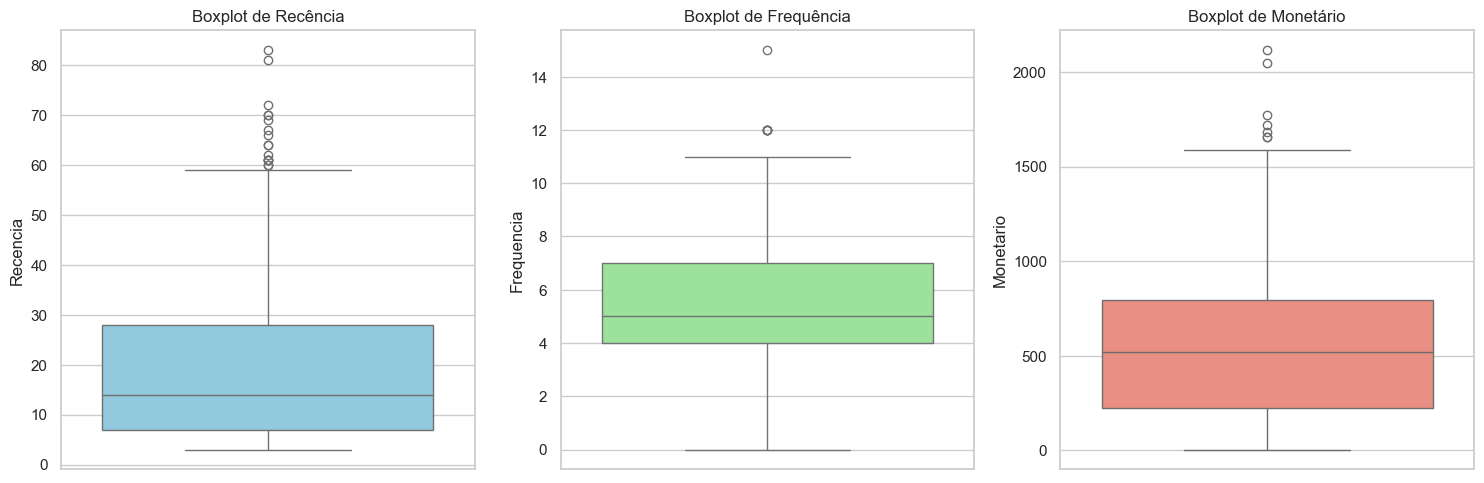

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definindo o estilo visual
sns.set_theme(style="whitegrid")

# Criando uma figura com 3 subplots (um para cada variável do RFM)
plt.figure(figsize=(15, 5))

# Plot Recência
plt.subplot(1, 3, 1)
sns.boxplot(y=df_rfm['Recencia'], color='skyblue')
plt.title('Boxplot de Recência')

# Plot Frequência
plt.subplot(1, 3, 2)
sns.boxplot(y=df_rfm['Frequencia'], color='lightgreen')
plt.title('Boxplot de Frequência')

# Plot Monetário
plt.subplot(1, 3, 3)
sns.boxplot(y=df_rfm['Monetario'], color='salmon')
plt.title('Boxplot de Monetário')

plt.tight_layout()
plt.show()

## Escalonamento (Feature Scaling)

Como a Recência é medida em dias (ex: 10) e o Monetário em Reais (ex: 1.000), você precisa usar o StandardScaler. Sem isso, o algoritmo dará um peso muito maior ao valor em dinheiro.


Equalização de Pesos: Como o K-Means utiliza a distância euclidiana, variáveis com grandes ordens de magnitude (como o Monetário) dominariam o cálculo. O StandardScaler centraliza a média em 0 e define o desvio padrão como 1, garantindo que Recência, Frequência e Valor tenham o mesmo peso na definição dos grupos.

Preparação para o Algoritmo: Esta padronização é um requisito matemático para algoritmos baseados em distância, permitindo uma convergência mais rápida e clusters mais equilibrados.

Aplicando o StandardScaler

In [47]:
from sklearn.preprocessing import StandardScaler

# 1. Instanciar o escalonador
scaler = StandardScaler()

# 2. Ajustar e transformar os dados (apenas as colunas numéricas do RFM)
# Importante: Usamos o df_rfm_clean (sem outliers) para que eles não distorçam a média
df_rfm_scaled = scaler.fit_transform(df_rfm_clean)

# 3. Converter de volta para DataFrame para facilitar a visualização
df_rfm_scaled = pd.DataFrame(
    df_rfm_scaled, 
    columns=df_rfm_clean.columns, 
    index=df_rfm_clean.index
)

print("Dados escalonados (primeiras linhas):")
print(df_rfm_scaled.head())

Dados escalonados (primeiras linhas):
            Recencia  Frequencia  Monetario
cliente_id                                 
1000       -0.512012    0.783406  -0.135973
1001       -0.364146    1.252050   0.418079
1002        0.005517    0.314761  -0.841495
1003       -0.290214   -1.091172   0.192051
1004       -0.142348    0.314761  -0.263635


## O Método do Cotovelo (Elbow Method)

Qual é o número ideal de grupos para esses clientes? 

Para isso, calculamos a Inércia (soma das distâncias quadradas dentro dos clusters) para diferentes valores de K.


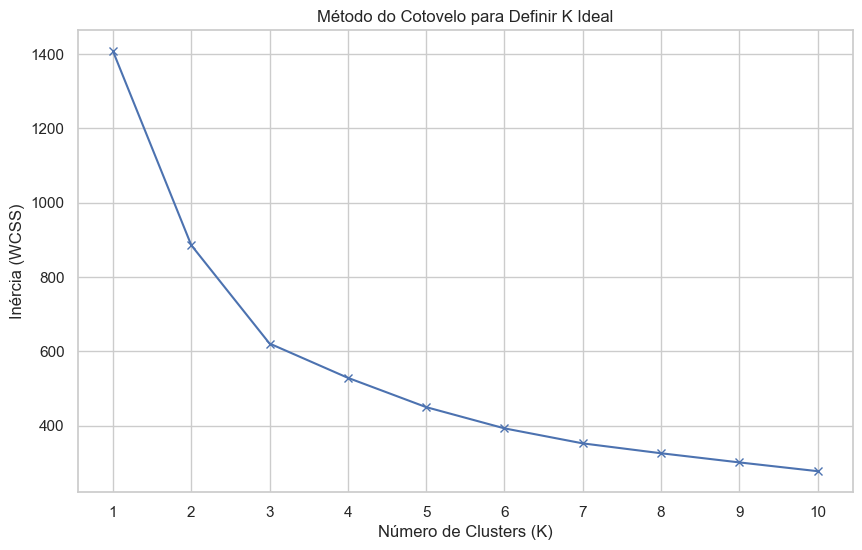

In [48]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Calcular a Inércia (WSS - Within-Cluster Sum of Square) para diferentes valores de K
wcss = []
K_range = range(1, 11) # Vamos testar de 1 a 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_rfm_scaled)
    wcss.append(kmeans.inertia_)

# 2. Plotar o Gráfico do Cotovelo
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, 'bx-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.title('Método do Cotovelo para Definir K Ideal')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [49]:
# 3. Visualmente, o "cotovelo" parece estar em K=3, então vamos treinar o modelo final com K=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(df_rfm_scaled)

# 4. Adicionando os rótulos ao DataFrame original (sem escala)
df_rfm_clean_copy = df_rfm_clean.copy()  # Criando uma cópia para evitar alterações indesejadas
df_rfm_clean_copy['Cluster'] = clusters

# Visualizando a média de cada cluster para entender os perfis
analise_clusters = df_rfm_clean_copy.groupby('Cluster').agg({
    'Recencia': 'mean',
    'Frequencia': 'mean',
    'Monetario': ['mean', 'count']
}).round(2)

print(analise_clusters)

        Recencia Frequencia Monetario      
            mean       mean      mean count
Cluster                                    
0          10.78       4.57    349.13   194
1          37.34       3.91    382.46   117
2          12.32       7.31    919.90   158


O que é a Inércia? "Ela mede a soma das distâncias ao quadrado entre cada ponto e o centro do seu cluster. Quanto menor a inércia, mais 'compactos' são os nossos grupos."

Por que o "Cotovelo"? "À medida que aumentamos K, a inércia sempre cai. O segredo é encontrar o ponto onde a queda deixa de ser brusca e se torna linear (o formato de um cotovelo). Escolher um K após esse ponto traria uma complexidade desnecessária sem ganho real de segmentação."

Decisão de Negócio: "Ao observar o gráfico, identificamos que o ponto de inflexão ocorre em K=3 (ou 4, dependendo do seu gráfico). Isso significa que dividir nossa base em 3 perfis distintos é o ideal para que o marketing consiga criar estratégias personalizadas e operáveis."

## Interpretação das Personas

Agora que temos os números médios de cada grupo, podemos dar "nomes" a eles

In [60]:
# Dicionário de Cores Padrão

cores_personas = {
    '0' : ['#f1c40f', 'Potenciais'],
    '1' : ['#e74c3c', 'Hibernando'],
    '2' : ['#2ecc71', 'Campeões']

}

In [77]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(df_rfm_scaled)

df_rfm_clean['Cluster'] = clusters

df_rfm_clean['Cluster'] = df_rfm_clean['Cluster'].astype(str)  # Convertendo para string para facilitar a visualização

df_rfm_clean['cores'] = df_rfm_clean['Cluster'].map( lambda x: cores_personas[x][0]) # Mapeando a cor para cada cluster

mapa_cores_plotly = {v[1]: v[0] for k, v in cores_personas.items()}

df_rfm_clean.head()

,Recencia,Frequencia,Monetario,Cluster,Persona,cores
cliente_id,,,,,,
1000,11.0,7,500.67,2,Campeões,#2ecc71
1001,13.0,8,700.57,2,Campeões,#2ecc71
1002,18.0,6,246.12,0,Potenciais,#f1c40f
1003,14.0,3,619.02,0,Potenciais,#f1c40f
1004,16.0,6,454.61,0,Potenciais,#f1c40f


In [78]:
import plotly.express as px

palette_seaborn = [cores_personas[k][0] for k in sorted(cores_personas.keys())]

# Criando o gráfico 3D
fig = px.scatter_3d(
    df_rfm_clean, 
    x='Recencia', 
    y='Frequencia', 
    z='Monetario',
    color='Persona',  # As cores serão divididas pelos clusters que criámos
    color_discrete_map=mapa_cores_plotly,
    title='Segmentação de Clientes: Visão 3D RFM',
    labels={'Recencia': 'Recência (Dias)', 'Frequencia': 'Frequência (Compras)', 'Monetario': 'Valor Monetário (R$)'},
    opacity=0.8,
    hover_data=[df_rfm_clean.index] # Mostra o ID do cliente ao passar o rato
)

# Ajustando o layout para ficar mais elegante
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

### 1. Cluster 0: Clientes "Potenciais" (Recém-Chegados)
Perfil: Recência baixíssima (10.7 dias), Frequência moderada (4.5) e Monetário médio (R$ 349,13).

O que diz o dado: Eles são os clientes mais "quentes" em termos de visita recente (a menor recência de todas), mas ainda não gastam tanto quanto os Campeões. Podem ser clientes novos que estão experimentando a marca.

Estratégia: Focar em Upselling e Cross-selling. Como eles estão ativos agora, é o momento de oferecer produtos complementares para aumentar o ticket médio.

### 2. Cluster 1: Clientes "Em Hibernação" (Alerta de Churn)
Perfil: Recência alta (37 dias), Frequência baixa (3.9) e Monetário médio (R$ 382,46).

O que diz o dado: Eles têm um gasto razoável, mas estão há mais de um mês sem comprar. Estão perdendo o hábito de compra na sua loja.

Estratégia: Reativação urgente. Campanhas de "Sentimos sua falta" com cupons de desconto por tempo limitado para trazê-los de volta antes que esqueçam a marca.

### 3. Cluster 2: Os "Campeões" (VIPs)
Perfil: Recência baixa (12 dias), Frequência alta (7.3 compras) e Monetário muito superior (R$ 919,90).

O que diz o dado: Este é o seu melhor grupo. Eles compram muito, com frequência e estiveram na loja recentemente.

Estratégia: Não precisam de descontos para comprar. O foco aqui é fidelização e exclusividade (mimos, antecipação de lançamentos e tratamento VIP).



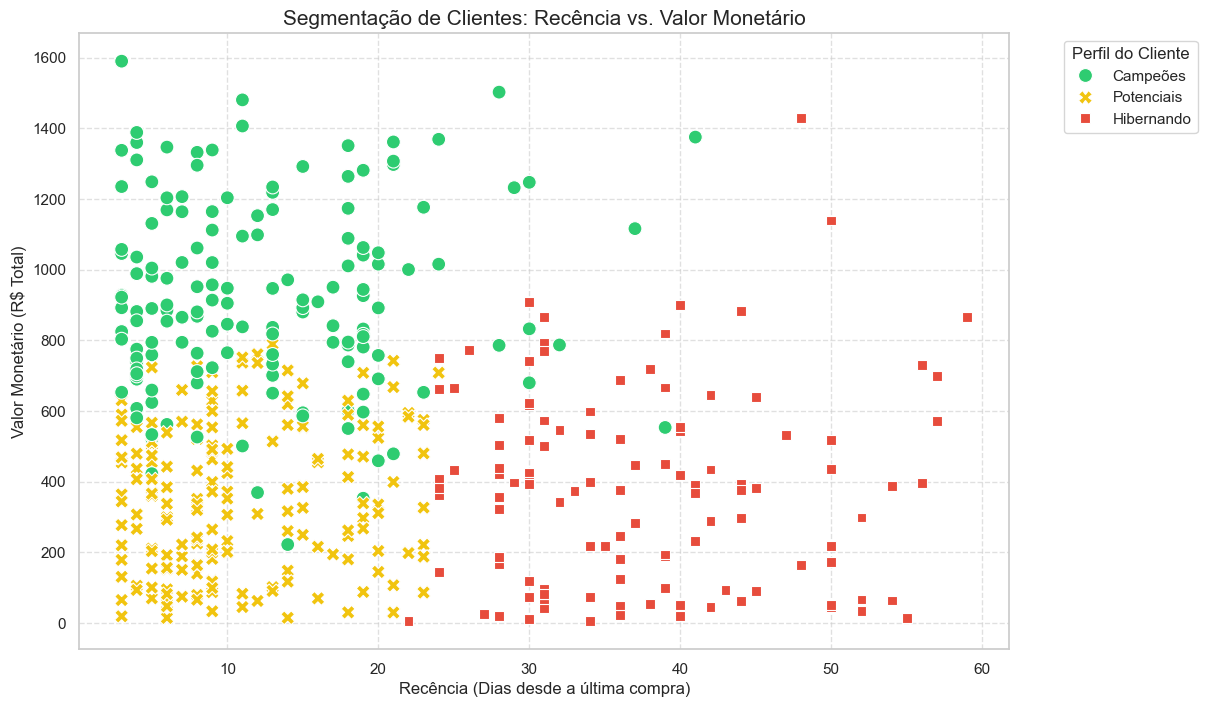

In [79]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_rfm_clean, 
    x='Recencia', 
    y='Monetario', 
    hue='Persona',      # Cor por Persona
    style='Persona',    # Formatos diferentes para cada grupo
    palette=mapa_cores_plotly,  # Esquema de cores elegante
    s=100               # Tamanho dos pontos
)

plt.title('Segmentação de Clientes: Recência vs. Valor Monetário', fontsize=15)
plt.xlabel('Recência (Dias desde a última compra)', fontsize=12)
plt.ylabel('Valor Monetário (R$ Total)', fontsize=12)
plt.legend(title='Perfil do Cliente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()